# 3. Olay çalışmaları: bilançolar ve yönetici alımları

## Araştırma soruları
1. **Bilanço tepkisi:** Bilanço açıklamasından sonraki iki gün, sıradan günlerden daha mı oynak?
2. **Bilanço sonrası sürüklenme (PEAD):** İlk tepkinin yönü sonraki iki ayda devam ediyor mu? Akademik literatürde küçük hisselerde görülür; büyük ve çok takip edilen Nasdaq 100 şirketlerinde de var mı?
3. **Yönetici alımları:** Yöneticiler kendi hisselerini piyasadan aldıktan sonra hisse piyasadan iyi gidiyor mu?

## Yöntem
- Olay tarihleri SEC'ten: bilanço için 8-K madde 2.02, yönetici işlemleri için Form 4.
- **Piyasa modeli:** her olay için olaydan 250 ile 30 gün önce arasında `getiri_hisse = α + β · getiri_endeks` tahmin edilir. Olay penceresindeki **anormal getiri** = gerçekleşen − modelin beklediği.
- **CAR** (kümülatif anormal getiri): pencere boyunca anormal getirilerin toplamı. Tepki = gün 0..1, sürüklenme = gün 2..40.
- Testler: tek örneklem t-testi (ortalama ≠ 0?), Welch t-testi (iki grup farkı), Spearman sıra korelasyonu.

In [1]:
import sys, sqlite3
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
from mi import db, stats as st, events as ev, charts
%matplotlib inline
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')
con = db.connect()
prices = pd.read_sql('SELECT * FROM prices', con)
close, volume = st.wide(prices), st.wide(prices, 'volume')
r = st.returns(close)
assets = pd.read_sql('SELECT * FROM assets', con).set_index('code')
print(f'{close.shape[1]} varlık, {close.index[0]:%Y-%m-%d} – {close.index[-1]:%Y-%m-%d}, {len(prices):,} fiyat satırı')

109 varlık, 2021-10-11 – 2026-10-09, 130,517 fiyat satırı


In [2]:
E = pd.read_sql("SELECT code, date FROM filings WHERE items LIKE '%2.02%'", con)
res = ev.earnings_study(r, E)
print(f"{res['n']} bilanço, {res['companies']} şirket, {res['period'][0]} – {res['period'][1]}")

894 bilanço, 91 şirket, 2023-05-04 – 2026-08-13


## 3.1 Bilanço günleri ne kadar oynak?

In [3]:
print(f"Bilanço sonrası 2 günlük ortalama |anormal getiri|: %{res['abs_react_mean']:.2f}")
print(f"Sıradan 2 günlük ortalama |fazla getiri|:         %{res['normal_2d_abs_mean']:.2f}")
print(f"Oran: {res['react_ratio']:.2f} kat")

Bilanço sonrası 2 günlük ortalama |anormal getiri|: %6.45
Sıradan 2 günlük ortalama |fazla getiri|:         %2.28
Oran: 2.83 kat


## 3.2 İlk tepki sürüyor mu?

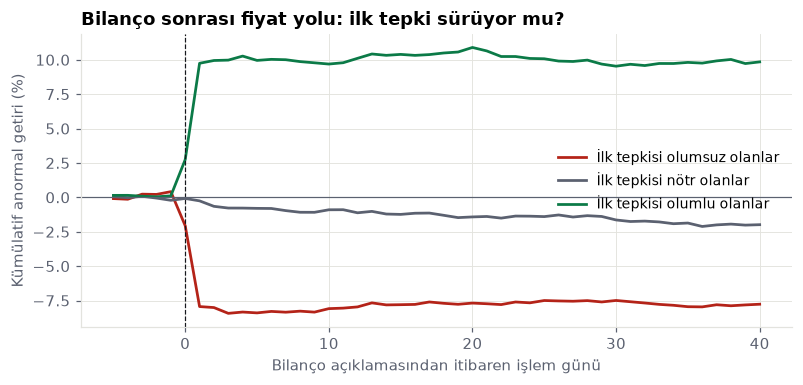

,n,mean,ci95,t,p,hit
olumsuz,298,0.17,"[-1.9719397947131119, 2.312467968024979]",0.16,0.88,46.31
nötr,298,-1.73,"[-3.0761165053402904, -0.38833169824718206]",-2.53,0.01,43.29
olumlu,298,0.10,"[-1.7232279752251671, 1.924891709843943]",0.11,0.91,51.68


In [4]:
charts.event_paths(res['path_days'], res['avg_path'], Path('/tmp/_p.png'))
from IPython.display import Image; display(Image('/tmp/_p.png'))
pd.DataFrame(res['drift_by_bucket']).T[['n', 'mean', 'ci95', 't', 'p', 'hit']]

In [5]:
d = res['drift_spread']; s = res['spearman']
print(f"Olumlu − olumsuz grup sürüklenme farkı: {d['diff']:.2f} puan, Welch t = {d['t']:.2f}, p = {d['p']:.3f}")
print(f"Tepki ile sonraki getiri arasında Spearman ρ = {s['rho']:.3f}, p = {s['p']:.3f}")
print('Sonuç:', 'Sürüklenme var: piyasa bilançoyu tek seferde fiyatlamıyor.' if d['p'] < .05 and d['diff'] > 0 else 'Sürüklenme yok: büyük şirketlerde bilgi hızla fiyatlanıyor (verimli piyasa ile uyumlu).')

Olumlu − olumsuz grup sürüklenme farkı: -0.07 puan, Welch t = -0.05, p = 0.961
Tepki ile sonraki getiri arasında Spearman ρ = 0.017, p = 0.615
Sonuç: Sürüklenme yok: büyük şirketlerde bilgi hızla fiyatlanıyor (verimli piyasa ile uyumlu).


## 3.3 En sert bilanço tepkileri

In [6]:
pd.DataFrame(res['biggest'])

,code,date,react,drift
0,DXCM,2024-07-25,-44.10,11.43
1,APP,2024-11-06,39.87,23.07
2,SNPS,2025-09-09,-37.06,1.97
3,DDOG,2026-05-07,34.61,26.54
4,ALAB,2024-11-04,32.10,36.04
5,PLTR,2024-02-05,29.62,-7.17
6,AXON,2024-11-07,29.38,-14.04
7,ALNY,2026-07-30,-29.33,24.63
8,FTNT,2024-08-06,26.30,4.87
9,DDOG,2025-11-06,25.86,-33.85


## 3.4 Yönetici alımları ve plansız satışlar

In [7]:
T = pd.read_sql('SELECT * FROM insider_trades', con)
ins = ev.insider_study(r, T)
pd.DataFrame({(k, w): v for k, d in ins.items() for w, v in d.items()}).T

n  mean median    t    p  \
alim          car20   24  6.99   7.93 2.48 0.02   
              car40   24 16.16  13.69 4.82 0.00   
plansiz_satis car20  266  2.09   0.90 2.07 0.04   
              car40  266  1.10   0.15 0.77 0.44   

                                                         ci95   hit  
alim          car20   [1.455547281785183, 12.515412068820314] 79.17  
              car40   [9.585091764540055, 22.735747916901396] 83.33  
plansiz_satis car20  [0.10822212183764135, 4.072806622713246] 53.76  
              car40  [-1.721709661903896, 3.9281960888065557] 50.75

## Sınırlamalar
- **Örneklem:** Yönetici alımları Nasdaq 100'de nadir; sonuçların güven aralığı geniş. Satışların çoğu önceden planlanmış (10b5-1) olduğu için yalnızca plansız satışlar incelendi.
- **Hayatta kalma yanlılığı:** Evren bugünkü Nasdaq 100 listesi; geçmişte endeksten çıkan şirketler dahil değil, bu da geçmiş getirileri olduğundan iyi gösterebilir.
- **Zamanlama:** 8-K'nın gün içi saati bilinmediği için tepki penceresi iki gün (0–1) alındı.
- **Beklenti verisi yok:** Bilanço "sürprizi" analist beklentisiyle değil, fiyat tepkisiyle ölçüldü.